En este cuaderno se estará realizando por consola una versión simple del famoso videojuego "Balatro" (sin comodínes ni upgrades).
El objetivo es dada una meta de puntos, alcanzarla antes de que se terminen las manos disponibles.
Los puntos se calcularán de la siguiente forma:
1. Se suman los valores de las cartas jugadas y se multiplican por la puntuación base.



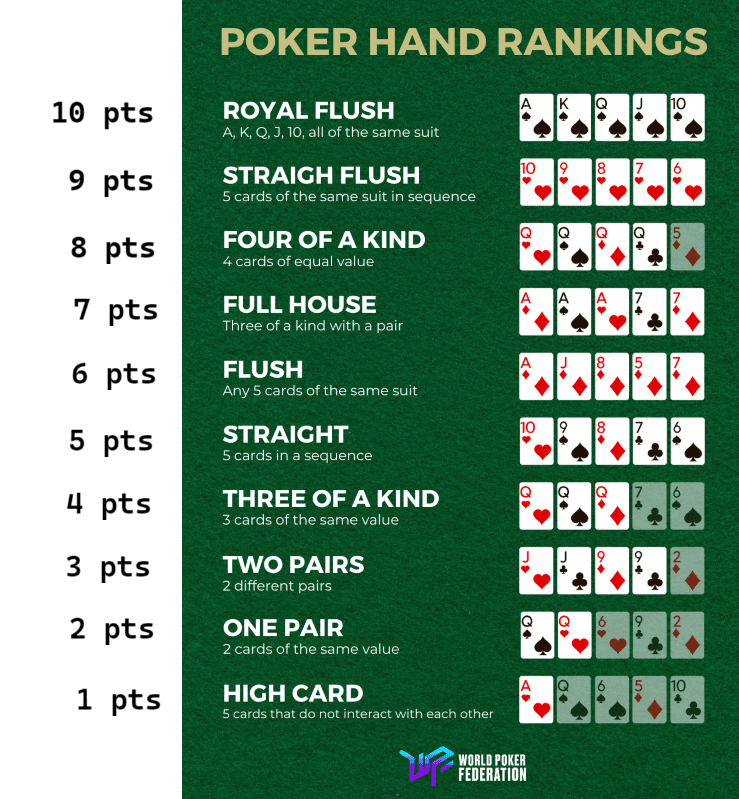

Los objetos a representar son:
1. Las cartas
2. El mazo
4. El juego

In [ ]:
import random
from google.colab import output
import time
from collections import Counter

In [ ]:
class Carta():

  simbolos = ["♠", "♥", "♣", "♦"]
  valores = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

  equivalencias = {
      "2": 2,
      "3": 3,
      "4": 4,
      "5": 5,
      "6": 6,
      "7": 7,
      "8": 8,
      "9": 9,
      "10": 10,
      "J": 11,
      "Q": 12,
      "K": 13,
      "A": 14
  }

  def __init__(self, simbolo, valor):
    self.simbolo = simbolo
    self.valor = valor

  def __str__(self):
    return f"[{self.valor} {self.simbolo}]"

  def __repr__(self):
    return self.__str__()

  def __eq__(self, other):
    return self.simbolo == other.simbolo and self.valor == other.valor

  def __hash__(self):
    return hash((self.simbolo, self.valor))

class Mazo():

  def __init__(self, fill_52=False):
    self.cartas = []
    if fill_52:
      self.fill_52()

  def fill_52(self):
    self.cartas = []
    for simbolo in Carta.simbolos:
      for valor in Carta.valores:
        self.cartas.append(Carta(simbolo, valor))

  def shuffle(self):
    random.shuffle(self.cartas)

  def pop_card(self):
    return self.cartas.pop()

  def add_card(self, carta):
    self.cartas.append(carta)

  def is_empty(self):
    return len(self.cartas) == 0

class Juego():

  manos = {
      "Royal flush": 10,
      "Straight flush": 9,
      "Four of a kind": 8,
      "Full house": 7,
      "Flush": 6,
      "Straight": 5,
      "Three of a kind": 4,
      "Two pairs": 3,
      "One pair": 2,
      "High card": 1
  }

  def __init__(self, tamano_mano=8, n_manos=4, n_descartes=4, meta=500):

    # Crear mazos
    self.mazo_master = Mazo(fill_52=True)
    self.mazo_master.shuffle()
    self.mazo_de_descarte = Mazo()
    self.mazo_del_jugador = Mazo()

    # Repartir cartas al jugador
    self.tamano_mano = tamano_mano
    for i in range(self.tamano_mano):
      self.mazo_del_jugador.add_card(self.mazo_master.pop_card())

    # Variables de gameplay
    self.n_manos = n_manos
    self.n_descartes = n_descartes
    self.meta = meta
    self.puntuacion = 0

    self.main_loop()

  def discard_cards_and_replace(self, pos_of_cards_to_discard):

    for pos in pos_of_cards_to_discard:
      carta = self.mazo_del_jugador.cartas[pos]
      self.mazo_de_descarte.add_card(carta)
      if not self.mazo_master.is_empty():
        self.mazo_del_jugador.cartas[pos] = self.mazo_master.pop_card()
      else:
        self.mazo_del_jugador.cartas[pos] = None

    self.mazo_del_jugador.cartas = [carta for carta in self.mazo_del_jugador.cartas if carta is not None]

  def show_game_stats(self):
    output.clear()
    print(f"Puntuación actual: {self.puntuacion}")
    print(f"Meta: {self.meta}")
    print(f"Número de descartes: {self.n_descartes}")
    print(f"Número de manos: {self.n_manos}")
    print(f"Cartas del jugador: {self.mazo_del_jugador.cartas}")

  @staticmethod
  def is_a_flush(cartas):
    return len(set([carta.simbolo for carta in cartas])) == 1

  @staticmethod
  def __is_a_straight(cartas, a_is_1=False):
    valores = map(lambda x: Carta.equivalencias[x], [carta.valor for carta in cartas])
    if a_is_1:
      valores = [1 if valor == 14 else valor for valor in valores]
    valores = sorted(valores)
    return all([valores[i+1] - valores[i] == 1 for i in range(len(valores)-1)])

  @staticmethod
  def is_a_straight(cartas):
    return Juego.__is_a_straight(cartas) or Juego.__is_a_straight(cartas, a_is_1=True)

  @staticmethod
  def is_a_straight_flush(cartas):
    return Juego.is_a_flush(cartas) and Juego.is_a_straight(cartas)

  @staticmethod
  def is_a_royal_flush(cartas):
    valores = [carta.valor for carta in cartas]
    return Juego.is_a_straight_flush(cartas) and "A" in valores and "K" in valores

  @staticmethod
  def __find_kinds(cartas):
    valores = [carta.valor for carta in cartas]
    pares, tripletas, cuadruples = [], [], []
    for valor, conteo in Counter(valores).items():
      valores_comunes = [carta for carta in cartas if carta.valor == valor]
      if conteo == 4:
        cuadruples.append(valores_comunes)
      if conteo == 3:
        tripletas.append(valores_comunes)
      if conteo == 2:
        pares.append(valores_comunes)

    return pares, tripletas, cuadruples

  @staticmethod
  def get_four_of_kind(cartas):
    pares, tripletas, cuadruples = Juego.__find_kinds(cartas)
    if len(cuadruples) > 0:
      return cuadruples[0]
    return None

  @staticmethod
  def get_full_house(cartas):
    pares, tripletas, cuadruples = Juego.__find_kinds(cartas)
    if len(tripletas) > 0 and len(pares) > 0:
      return tripletas[0] + pares[0]

  @staticmethod
  def get_three_of_kind(cartas):
    pares, tripletas, cuadruples = Juego.__find_kinds(cartas)
    if len(tripletas) > 0:
      return tripletas[0]
    return None

  @staticmethod
  def get_two_pairs(cartas):
    pares, tripletas, cuadruples = Juego.__find_kinds(cartas)
    if len(pares) > 1:
      return pares[0] + pares[1]
    return None

  @staticmethod
  def get_one_pair(cartas):
    pares, tripletas, cuadruples = Juego.__find_kinds(cartas)
    if len(pares) > 0:
      return pares[0]
    return None

  @staticmethod
  def get_high_card(cartas):
    return [sorted(a, key=lambda x: Carta.equivalencias[x.valor])[-1]]

  @staticmethod
  def get_played_hand(cartas):
    if Juego.is_a_royal_flush(cartas) and len(cartas) == 5:
      return "Royal flush", cartas
    if Juego.is_a_straight_flush(cartas) and len(cartas) == 5:
      return "Straight flush", cartas
    fok = Juego.get_four_of_kind(cartas)
    if fok:
      return "Four of a kind", fok
    fh = Juego.get_full_house(cartas)
    if fh:
      return "Full house", fh
    if Juego.is_a_flush(cartas) and len(cartas) == 5:
      return "Flush", cartas
    if Juego.is_a_straight(cartas) and len(cartas) == 5:
      return "Straight", cartas
    tok = Juego.get_three_of_kind(cartas)
    if tok:
      return "Three of a kind", tok
    tp = Juego.get_two_pairs(cartas)
    if tp:
      return "Two pairs", tp
    op = Juego.get_one_pair(cartas)
    if op:
      return "One pair", op
    hc = Juego.get_high_card(cartas)
    return "High card", hc

  @staticmethod
  def get_hand_score(mano, cartas):
    multiplicador = Juego.manos[mano]
    suma_de_valores = sum([Carta.equivalencias[carta.valor] for carta in cartas])
    resultado = multiplicador * suma_de_valores
    print(f"Scored a {mano} with {multiplicador}x{suma_de_valores} = {resultado}!")
    return resultado

  def main_loop(self):

    while True:

      self.show_game_stats()

      # Etapa de descarte
      while True:
        if self.n_descartes > 0:
          cartas_a_descartar = input("Indique la posición de las cartas que quiere descartar (separadas por coma):")
          if cartas_a_descartar == "":
            break
          cartas_a_descartar = [int(i) for i in cartas_a_descartar.split(",")]
          print(f"Descartando {[self.mazo_del_jugador.cartas[pos] for pos in cartas_a_descartar]}")
          self.discard_cards_and_replace(cartas_a_descartar)
          self.n_descartes -= 1
          time.sleep(2)
          self.show_game_stats()
        else:
          print("No quedan descartes")
          break

      # Etapa de jugar mano
      cartas_a_jugar_pos = input("Indique la posición de las cartas que quiere jugar (separadas por coma):")
      cartas_a_jugar_pos = [int(i) for i in cartas_a_jugar_pos.split(",")]
      cartas_a_jugar = [self.mazo_del_jugador.cartas[pos] for pos in cartas_a_jugar_pos]
      print(f"Jugando {cartas_a_jugar}")
      self.puntuacion += Juego.get_hand_score(*Juego.get_played_hand(cartas_a_jugar))
      self.discard_cards_and_replace(cartas_a_jugar_pos)

      self.n_manos -= 1

      if self.puntuacion >= self.meta:
        print("Excelente! Llegaste a la meta :D")
        break

      if self.n_manos == 0:
        print("Game Over! No llegaste a la meta :(")
        break

      input()


In [ ]:
a = [Carta("♥", "K"), Carta("♣", "K"), Carta("♥", "4"), Carta("♥", "5"), Carta("♦", "4")]
Juego.get_hand_score(*Juego.get_played_hand(a))

Scored a Two pairs with 3x34 = 102!


102

In [ ]:
juego = Juego()

Puntuación actual: 217
Meta: 500
Número de descartes: 2
Número de manos: 3
Cartas del jugador: [[Q ♦], [Q ♣], [J ♦], [8 ♣], [K ♠], [A ♥], [4 ♦], [10 ♦]]
Indique la posición de las cartas que quiere descartar (separadas por coma):
Indique la posición de las cartas que quiere jugar (separadas por coma):0,2,4,5,7
Jugando [[Q ♦], [J ♦], [K ♠], [A ♥], [10 ♦]]
Scored a Straight with 5x60 = 300!
Excelente! Llegaste a la meta :D
